# TV Audience Analytics with Apache Spark

## Project Overview

This project explores television viewing activity and household demographics using PySpark on Databricks. It combines two coursework assignments from the Distributed Database Management course at Technion.

**Part 1 — Large-Scale Viewing Analysis** uses Spark DataFrames to analyze genre popularity, household viewing activity, and television markets. It also applies predefined rules to flag program airings and computes demographic market scores. The saved run includes approximately **34.3 million viewing events**.

**Part 2 — Audience Segmentation and Streaming** builds household feature vectors, explores them with PCA, and applies K-means clustering. It compares station preferences across clusters and subsets, then extends the analysis to Kafka events using Spark Structured Streaming and cumulative counts stored in Delta Lake.

**Technologies:** Python, PySpark, Spark MLlib, Spark Structured Streaming, Kafka, Delta Lake, Databricks, and Matplotlib.

### About This Notebook

The two parts use separate course datasets and retain their original code and saved outputs. Results were produced in the university Databricks environment; the combined notebook has not been rerun as a single workflow. Access to the original data and infrastructure is currently unavailable, so local execution requires replacement data and environment configuration.

The suspicious-program rules are part of the coursework scenario, not a validated fraud-detection model. The streaming section demonstrates micro-batch processing rather than a production deployment.

### Contents

- [Part 1 — Large-Scale Viewing Analysis](#part-1)
  - Data sources and loading
  - Part A: Viewing activity analysis
  - Part B: Rule-based program detection
  - Part C: Market scoring
- [Part 2 — Audience Segmentation and Streaming](#part-2)
  - Data sources and loading
  - Part A: Audience segmentation
    - Feature extraction and visual analysis
    - Clustering and household subsets
    - Station preferences by cluster
  - Part B: Incremental streaming analysis

<a id="part-1"></a>
## Part 1 — Large-Scale Viewing Analysis

### Data Sources

The first part combines four datasets:

| Dataset | Contents | Main join keys |
|---|---|---|
| Demographics | Household composition, income, net worth, vehicle ownership, and other attributes | `household_id` |
| Daily programs | Program titles, genres, airing dates and times, and scheduled durations | `prog_code` |
| Viewing events | Device-level viewing records with event dates, times, stations, and program codes | `device_id`, `prog_code` |
| Device reference | Links devices to households and designated market areas (DMAs) | `device_id`, `household_id` |

The saved run contains approximately **34.3 million viewing events**, **13.2 million daily program records**, **203.6 million reference records**, and **357,721 demographic records**. These are input row counts, not counts of unique entities.

### Loading the Data

The following cells load the datasets from the original Databricks storage locations and inspect their schemas and sample records. CSV inputs use explicit schemas, while the device reference data is read from Parquet.

Later calculations join only the fields needed for each task and apply task-specific filtering and duplicate handling.

In [0]:
from pyspark import SparkContext
from pyspark.sql import SparkSession
 
spark = SparkSession.builder.appName("my_project_1").getOrCreate()


In [0]:
from pyspark.sql.types import *
from pyspark.sql.functions import *

In [0]:
# Read a CSV into a dataframe
# There is a smarter version, that will first check if there is a Parquet file and use it
def load_csv_file(filename, schema):
  """
  Reads the relevant file from distributed file system using the given schema
  """


   # remove #df = spark.read.csv("/Volumes/dbr_lab/raw/input_data/STB tuning data/FWM_20150104_R.pd.gz", header=True)
  allowed_files = {'Daily program data': ('Daily program data', "|"),
                   'demographic': ('demographic', "|")}

  if filename not in allowed_files.keys():
    print(f'You were trying to access unknown file \"{filename}\". Only valid options are {allowed_files.keys()}')
    return None

  filepath = allowed_files[filename][0]
  dataPath = f"/Volumes/dbr_lab/raw/input_data/{filepath}"
  delimiter = allowed_files[filename][1]

  df = spark.read.format("csv")\
    .option("header","false")\
    .option("delimiter",delimiter)\
    .schema(schema)\
    .load(dataPath)
  return df
# This dict holds the correct schemata for easily loading the CSVs
schemas_dict = {'Daily program data':
                  StructType([
                    StructField('prog_code', StringType()),
                    StructField('title', StringType()),
                    StructField('genre', StringType()),
                    StructField('air_date', StringType()),
                    StructField('air_time', StringType()),
                    StructField('Duration', FloatType())
                  ]),
                'viewing':
                  StructType([
                    StructField('device_id', StringType()),
                    StructField('event_date', StringType()),
                    StructField('event_time', IntegerType()),
                    StructField('mso_code', StringType()),
                    StructField('prog_code', StringType()),
                    StructField('station_num', StringType())
                  ]),
                'demographic':
                  StructType([StructField('household_id',StringType()),
                    StructField('household_size',IntegerType()),
                    StructField('num_adults',IntegerType()),
                    StructField('num_generations',IntegerType()),
                    StructField('adult_range',StringType()),
                    StructField('marital_status',StringType()),
                    StructField('race_code',StringType()),
                    StructField('presence_children',StringType()),
                    StructField('num_children',IntegerType()),
                    StructField('age_children',StringType()), #format like range - 'bitwise'
                    StructField('age_range_children',StringType()),
                    StructField('dwelling_type',StringType()),
                    StructField('home_owner_status',StringType()),
                    StructField('length_residence',IntegerType()),
                    StructField('home_market_value',StringType()),
                    StructField('num_vehicles',IntegerType()),
                    StructField('vehicle_make',StringType()),
                    StructField('vehicle_model',StringType()),
                    StructField('vehicle_year',IntegerType()),
                    StructField('net_worth',IntegerType()),
                    StructField('income',StringType()),
                    StructField('gender_individual',StringType()),
                    StructField('age_individual',IntegerType()),
                    StructField('education_highest',StringType()),
                    StructField('occupation_highest',StringType()),
                    StructField('education_1',StringType()),
                    StructField('occupation_1',StringType()),
                    StructField('age_2',IntegerType()),
                    StructField('education_2',StringType()),
                    StructField('occupation_2',StringType()),
                    StructField('age_3',IntegerType()),
                    StructField('education_3',StringType()),
                    StructField('occupation_3',StringType()),
                    StructField('age_4',IntegerType()),
                    StructField('education_4',StringType()),
                    StructField('occupation_4',StringType()),
                    StructField('age_5',IntegerType()),
                    StructField('education_5',StringType()),
                    StructField('occupation_5',StringType()),
                    StructField('polit_party_regist',StringType()),
                    StructField('polit_party_input',StringType()),
                    StructField('household_clusters',StringType()),
                    StructField('insurance_groups',StringType()),
                    StructField('financial_groups',StringType()),
                    StructField('green_living',StringType())
                  ])
}

#### Household Demographics

Load the demographic records and inspect their schema and sample rows.

In [0]:
%%time
# demographic data filename is 'demographic'
demo_df = load_csv_file('demographic', schemas_dict['demographic'])
print("lines in table:", demo_df.count())
demo_df.printSchema()
print(f'demo_df contains {demo_df.count()} records!')
display(demo_df.limit(6))

lines in table: 357721
root
 |-- household_id: string (nullable = true)
 |-- household_size: integer (nullable = true)
 |-- num_adults: integer (nullable = true)
 |-- num_generations: integer (nullable = true)
 |-- adult_range: string (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- race_code: string (nullable = true)
 |-- presence_children: string (nullable = true)
 |-- num_children: integer (nullable = true)
 |-- age_children: string (nullable = true)
 |-- age_range_children: string (nullable = true)
 |-- dwelling_type: string (nullable = true)
 |-- home_owner_status: string (nullable = true)
 |-- length_residence: integer (nullable = true)
 |-- home_market_value: string (nullable = true)
 |-- num_vehicles: integer (nullable = true)
 |-- vehicle_make: string (nullable = true)
 |-- vehicle_model: string (nullable = true)
 |-- vehicle_year: integer (nullable = true)
 |-- net_worth: integer (nullable = true)
 |-- income: string (nullable = true)
 |-- gender_individua

household_id,household_size,num_adults,num_generations,adult_range,marital_status,race_code,presence_children,num_children,age_children,age_range_children,dwelling_type,home_owner_status,length_residence,home_market_value,num_vehicles,vehicle_make,vehicle_model,vehicle_year,net_worth,income,gender_individual,age_individual,education_highest,occupation_highest,education_1,occupation_1,age_2,education_2,occupation_2,age_3,education_3,occupation_3,age_4,education_4,occupation_4,age_5,education_5,occupation_5,polit_party_regist,polit_party_input,household_clusters,insurance_groups,financial_groups,green_living
00000015,2,2,1,000000000000100000000,S,B,null,null,0000000000000000000,000000000000000,S,O,5,E,null,null,null,null,6,4,M,60,4,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,D,443,02C3,08C3,null
00000024,2,2,1,000000000100000000000,null,W,null,null,0000000000000000000,000000000000000,M,O,null,F,null,null,null,null,7,7,F,46,3,Z,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,R,223,09O3,03O3,null
00000026,null,null,null,000000000000000000000,null,null,null,null,0000000000000000000,000000000000000,S,null,null,F,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,46G,04CG,08CG,null
00000028,3,2,2,000000110000000000000,S,W,Y,1,0000010000000000000,000001000000000,S,O,3,H,null,null,null,null,5,7,M,38,2,4,null,null,34,1,7,null,null,null,null,null,null,null,null,null,null,V,473,11R3,09C3,1
00000035,1,1,1,000000000100000000000,null,W,null,null,0000000000000000000,000000000000000,null,null,null,G,null,null,null,null,4,null,M,50,2,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,D,523,13C3,08C3,null
00000036,null,null,null,000000000000000000000,null,null,null,null,0000000000000000000,000000000000000,null,null,null,G,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,51G,10RG,10RG,null


CPU times: user 1.03 s, sys: 49.8 ms, total: 1.08 s
Wall time: 11.7 s


#### Daily Program Records

Load program metadata, including titles, genres, airing times, and scheduled durations.

In [0]:
%%time
# daily_program data filename is 'Daily program data'
daily_prog_df = load_csv_file('Daily program data', schemas_dict['Daily program data'])

daily_prog_df.printSchema()
print(f'daily_prog_df contains {daily_prog_df.count()} records!')
display(daily_prog_df.limit(6))

root
 |-- prog_code: string (nullable = true)
 |-- title: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- air_date: string (nullable = true)
 |-- air_time: string (nullable = true)
 |-- Duration: float (nullable = true)

daily_prog_df contains 13194849 records!


prog_code,title,genre,air_date,air_time,Duration
EP000000351271,60 Minutes,Newsmagazine,20151228,000000,60.0
EP000000351271,60 Minutes,Newsmagazine,20151228,010000,60.0
EP000000351271,60 Minutes,Newsmagazine,20151228,020000,60.0
EP000000351271,60 Minutes,Newsmagazine,20151228,030000,60.0
EP000000510001,A Different World,Sitcom,20151227,050000,32.0
EP000000510001,A Different World,Sitcom,20151227,080000,32.0


CPU times: user 60.6 ms, sys: 7.01 ms, total: 67.7 ms
Wall time: 7.61 s


#### Viewing Events

Load the viewing-event CSV files using an explicit schema.

In [0]:
from pyspark.sql.types import StructType, StructField, StringType

viewing_schema = StructType([
    StructField("mso_code", StringType(), True),
    StructField("device_id", StringType(), True),
    StructField("event_date", StringType(), True),
    StructField("event_time", StringType(), True),
    StructField("station_num", StringType(), True),
    StructField("prog_code", StringType(), True),
])

viewing_df = (
    spark.read
    .option("header", "true")
    .schema(viewing_schema)
    .csv("dbfs:/FileStore/project_data/viewing_data_csv")
)

display(viewing_df.limit(6))
print(f"viewing_df contains {viewing_df.count()} rows!")

mso_code,device_id,event_date,event_time,station_num,prog_code
01540,000000d8b507,20150426,20000,66268,EP000809390271
06540,0000040277b6,20150426,21952,10057,EP018300020017
08360,001ac3304650,20150426,200000,19612,EP014194780094
08360,0021be163836,20150426,214148,32645,SP003140300000
100014,000000860cea,20150426,20400,10918,MV001780010000
17719,0000002784d7,20150426,201354,16374,EP021609450003


viewing_df contains 34305556 rows!


#### Device Reference

Load device-to-household and market mappings from Parquet.

The supplied reference extract omits the original System Type field.

In [0]:
outputPath = "dbfs:/FileStore/project_data/ref_data_parquet"

ref_data = spark.read.parquet(outputPath)

ref_data.printSchema()
display(ref_data.limit(6))
print(f"ref_data contains {ref_data.count()} rows!")

root
 |-- device_id: string (nullable = true)
 |-- dma: string (nullable = true)
 |-- dma_code: integer (nullable = true)
 |-- household_id: integer (nullable = true)
 |-- zipcode: integer (nullable = true)



device_id,dma,dma_code,household_id,zipcode
00000008354e,Toledo,547,1522829,43434
0000009ef08e,Toledo,547,1522829,43434
0000037bb803,Toledo,547,1522829,43434
0000006610c1,Toledo,547,1438798,43460
00000066807b,Toledo,547,1438798,43460
00000070b3ca,Toledo,547,1438798,43460


ref_data contains 203581233 rows!


### Part A — Viewing Activity Analysis

Use Spark DataFrames to express each calculation as a Map stage followed by a Reduce stage. The queries examine genre popularity, household activity, prime-time viewing, and program duration totals.

#### Data Preprocessing

Split comma-separated genres into individual labels and trim whitespace. Prepare device mappings with known DMA codes and flag viewing events between 18:00:00 and 23:00:00, including both endpoints. These transformations are used only by the queries that require them.

In [0]:
daily_prog_df_with_genres = (
    daily_prog_df
    .filter(col("genre").isNotNull())
    .withColumn("single_genre", explode(split(col("genre"), ",")))
    .withColumn("single_genre", trim(col("single_genre")))
)

In [0]:
ref_data_cleaned = (ref_data
                    .filter(col("dma_code").isNotNull())
)

In [0]:
viewing_with_time = (
    viewing_df
    .withColumn("event_time", col("event_time").cast("int"))
    .withColumn(
        "is_prime_time",
        (col("event_time") >= 180000) &
        (col("event_time") <= 230000)
    )
)

#### Question 1 — Most-Watched Genres

Count viewing events for each genre and return the top 10. Each event contributes once to every distinct genre associated with its program code.

In [0]:
daily_prog_df_with_genres_small = (
    daily_prog_df_with_genres
    .select("prog_code", "single_genre")
    .dropDuplicates()
)

In [0]:
#Map stage
#Maps program codes to genres and flags each entry in views data with a value of 1.

mapped_df = (
    viewing_df.
    select("prog_code")
    .join(
        broadcast(daily_prog_df_with_genres_small),
        on="prog_code",
        how="inner"
    )
    .selectExpr("single_genre as Genre", "1 as value")    
)

In [0]:
#Reduce stage 
#Aggregates total views by genre, sums values and identifies the top 10 categories

reduced_df = (
    mapped_df
    .groupBy("Genre")
    .agg(sum("value").alias("Total Number of Views"))
    .orderBy(desc("Total Number of Views"))
    .limit(10)
)

In [0]:
display(reduced_df)

Genre,Total Number of Views
News,5061183
Reality,5041360
Talk,2711022
Sitcom,2478753
Drama,2440776
Comedy,2316460
Documentary,2228203
Adventure,2168318
Sports event,1982816
Children,1874882


#### Question 2 — Selected-Genre Views by Household

Identify households with more than 500 viewing events for Crime, News, or Politics. Count each qualifying event once, even if the program matches multiple selected genres. No time-of-day filter is applied.

In [0]:
daily_prog_df_with_genres_small = (
    daily_prog_df_with_genres
    .select("prog_code", "single_genre")
    .filter(col("single_genre").isin("Crime", "News", "Politics"))
    .dropDuplicates(["prog_code"])
)

ref_data_small = (
    ref_data
    .select("device_id", "household_id")
    .dropDuplicates()
)

viewing_small = (
    viewing_df
    .select("device_id", "prog_code")
)

In [0]:
#Map stage
#Joins viewing and reference data to map household IDs to a constant value of 1 each time they watched suspicious late-night broadcasts
mapped_df = (
    viewing_small.join(
        broadcast(daily_prog_df_with_genres_small),
        on="prog_code",
        how="inner"
    )
    .join(
        broadcast(ref_data_small),
        on="device_id",
        how="inner"
    )
    .selectExpr("household_id as key", "1 as value")    
)

In [0]:
# Reduce Stage
# Adds total suspicious views per household ID and keeps those > 500
reduced_df = (
    mapped_df
    .groupBy("key")
    .agg(sum("value").alias("Number of Suspicious Views"))
    .filter(col("Number of Suspicious Views") > 500)
    .withColumnRenamed("key", "Household ID")
    .orderBy(desc("Number of Suspicious Views"))
)

In [0]:
display(reduced_df)

Household ID,Number of Suspicious Views
2881062,1031
3619572,723
2460935,672
3596779,662
390094,634
53940,580
408274,558
70189,557
3593105,514
2314729,510


#### Question 3 — Prime-Time Viewing by Market

Count viewing events per DMA between 18:00:00 and 23:00:00, including both endpoints. Rank markets by total event count, using viewing time rather than scheduled airing time.

In [0]:
#Map stage
# Filters prime-time data and maps each DMA-associated device
mapped_df = (
    viewing_with_time
    .filter(col("is_prime_time") == True)
    .select("device_id")
    .join(
        broadcast(ref_data_cleaned.select("device_id", "dma").dropDuplicates()),
        on="device_id",
        how="inner"
    )
    .selectExpr("dma as key", "1 as value")
)

In [0]:
#Reduce stage
#Sums prime time views per DMA and sorts in descending order
reduced_df = (
    mapped_df
    .groupBy("key")
    .agg(sum("value").alias("Total Prime Time Views"))
    .withColumnRenamed("key", "DMA")
    .orderBy(desc("Total Prime Time Views"))
)

In [0]:
display(reduced_df)

DMA,Total Prime Time Views
Charleston-Huntington,1032393
Wilkes Barre-Scranton-Hztn,953628
Seattle-Tacoma,559692
Greenville-N.Bern-Washngtn,549001
Amarillo,429496
Parkersburg,411381
Harrisburg-Lncstr-Leb-York,408580
Bluefield-Beckley-Oak Hill,396488
Little Rock-Pine Bluff,389868
Tyler-Longview(Lfkn&Ncgd),389623


#### Question 4 — Program Duration Totals

Rank programs by summing the selected program duration for every matched viewing event. The original output is labelled “Total DVR Playback Duration”, but the implementation includes all matched events and does not measure actual watch time or isolate DVR playback.

In [0]:
program_small = (
    daily_prog_df
    .select("prog_code", "title", "Duration")
    .dropDuplicates(["prog_code"])
)

viewing_small = (
    viewing_df
    .select("prog_code")
)

In [0]:
#Map stage
#Maps each stream record to its duration. Transforms each record into (prog_code, title, duration).
mapped_df = (
    viewing_small
    .join(
        program_small, 
        on="prog_code", 
        how="inner")
    .selectExpr(
        "prog_code as key",
        "title as title",
        "Duration as value"
    )    
)

In [0]:
#Reduce stage
#Sums duration per program code and sorts by total time descending
reduced_df = (
    mapped_df
    .groupBy("key", "title")
    .agg(sum("value").alias("Total DVR Playback Duration"))
    .withColumnRenamed("key", "Program Code")
    .withColumnRenamed("title", "Program Title")
    .orderBy(desc("Total DVR Playback Duration"))
)

In [0]:
display(reduced_df)

Program Code,Program Title,Total DVR Playback Duration
EP019225420001,2015 Masters Tournament,3.761256E7
EP005544654384,NASCAR Racing,3.659664E7
SH000199170000,SportsCenter,2.85339E7
SP003194120000,College Football,2.315088E7
MV000120060000,The Godfather,2.166144E7
MV000119950000,"The Godfather, Part II",2.150901E7
EP019667630022,2015 U.S. Open Tennis,1.833648E7
SH005456030000,On Demand,1.822296E7
EP015703650092,Live From,1.704846E7
MV003512660000,The Help,1.544256E7


### Part B — Rule-Based Program Detection

Score each daily program record using ten predefined conditions. Each satisfied condition contributes one point. Most conditions identify qualifying program codes and attach a flag through a left join, avoiding one large join of all raw datasets. Unmatched flags contribute zero points.

The explanations below describe the preserved original implementation, including its program-level genre check and duration baseline.

In [0]:
programs_scored = (daily_prog_df
                    .withColumn("suspicious_score", lit(0))
                    .drop("genre")
)

#### Condition 1 — Above-Average Duration

Add one point when a record's duration exceeds the average calculated from one retained duration per `prog_code`. The original code uses Spark's duplicate selection when a program has multiple duration values.

In [0]:
unique_programs_duration = (
    daily_prog_df
    .select("prog_code", "Duration")
    .dropDuplicates(["prog_code"])
)

avg_duration = unique_programs_duration.select(
    avg("Duration")
).first()[0]

In [0]:
programs_scored = programs_scored.withColumn(
    "suspicious_score",
    col("suspicious_score") +
    when(col("Duration") > avg_duration, 1).otherwise(0) 
).drop("Duration")

#### Condition 2 — Viewed by a Toyota-Owning Household

Add one point if the program was viewed at least once by a device belonging to a household with vehicle make code `91` (Toyota).

In [0]:
view_ref_df = (viewing_df
              .select("prog_code", "device_id")
              .dropDuplicates()
              .join(
                  ref_data.select("device_id", "household_id").dropDuplicates(),
                  on="device_id",
                  how="inner"
              ))

In [0]:
toyota_prog = (
    view_ref_df
    .join(
        demo_df
        .filter(col("vehicle_make") == 91)
        .select("household_id")
        .dropDuplicates(),
        on="household_id",
        how="left_semi"
    )
    .select("prog_code")
    .dropDuplicates(["prog_code"])
    .withColumn("cond2_toyota", lit(True))
)

In [0]:
programs_scored = (
    programs_scored
    .join(toyota_prog, on="prog_code", how="left")
    .fillna(False, subset=["cond2_toyota"])
    .withColumn(
        "suspicious_score",
        col("suspicious_score") +
        when(col("cond2_toyota"), 1).otherwise(0)
    )
    .drop("cond2_toyota")
)

#### Condition 3 — Two Adults with Similar Ages

Add one point if the program was viewed by a household with exactly two adults whose recorded ages differ by no more than six years.

In [0]:
adults = (
    view_ref_df
    .join(
        demo_df
        .filter(col("num_adults") == 2)
        .filter(abs(col("age_individual") - col("age_2")) <= 6)
        .select("household_id")
        .dropDuplicates(),
        on="household_id",
        how="left_semi"
    )
    .select("prog_code")
    .dropDuplicates(["prog_code"])
    .withColumn("cond3_adults", lit(True))
)

In [0]:
programs_scored = (
    programs_scored
    .join(adults, on="prog_code", how="left")
    .fillna(False, subset=["cond3_adults"])
    .withColumn(
        "suspicious_score",
        col("suspicious_score") +
        when(col("cond3_adults"), 1).otherwise(0)
    )
    .drop("cond3_adults")
)

#### Condition 4 — Overnight Airing

Add one point if the program aired at least once after 01:00:00 and before 05:00:00. The original code excludes both endpoints and uses airing time rather than viewing time.

In [0]:
night_airings_prog = (
    daily_prog_df
    .select("prog_code", "air_time")
    .withColumn("air_time", col("air_time").cast("int"))
    .filter((col("air_time") > 10000) & (col("air_time") < 50000))
    .dropDuplicates(["prog_code"]) 
    .select("prog_code")
    .withColumn("cond4_night_airing", lit(1))
)

programs_scored = (
    programs_scored
    .join(broadcast(night_airings_prog), on="prog_code", how="left")
    .fillna(0, subset=["cond4_night_airing"])
    .withColumn("suspicious_score", col("suspicious_score") + col("cond4_night_airing"))
    .drop("cond4_night_airing")
)

#### Condition 5 — Multiple Devices and Below-Average Income

Convert income codes A–D to 10–13, then identify households with more than three distinct devices and below-average income. Add one point to programs viewed by any qualifying household.

In [0]:
demo_income = (
    demo_df
    .filter(col("income").isNotNull())
    .withColumn(
        "income_num",
        when(col("income") == "A", 10)
        .when(col("income") == "B", 11)
        .when(col("income") == "C", 12)
        .when(col("income") == "D", 13)
        .otherwise(col("income").cast("int"))
    )
    .select("household_id", "income_num")
)

In [0]:
avg_income = (
    demo_income
    .select(avg("income_num"))
    .first()[0]
)

In [0]:
households_many_devices_low_income = (
    ref_data
    .select("household_id", "device_id")
    .join(broadcast(demo_income), on="household_id", how="inner")
    .filter(col("income_num") < avg_income)
    .groupBy("household_id")
    .agg(countDistinct("device_id").alias("num_devices"))
    .filter(col("num_devices") > 3)
    .select("household_id")
    .dropDuplicates()
)

In [0]:
programs_scored = (
    programs_scored
    .join(
        view_ref_df
        .join(households_many_devices_low_income, on="household_id", how="left_semi")
        .select("prog_code")
        .dropDuplicates(["prog_code"])
        .withColumn("cond5_devices_income", lit(True)), 
        on="prog_code", 
        how="left")
    .fillna(False, subset=["cond5_devices_income"])
    .withColumn(
        "suspicious_score",
        col("suspicious_score") + col("cond5_devices_income").cast("int")
    )
    .drop("cond5_devices_income")
)

#### Condition 6 — Selected Genres

Add one point if any genre record for the program code matches Crime, Politics, Talk, Public affairs, Reality, or Drama. Matching is case-sensitive. In this original implementation, the flag is shared by all records with the same `prog_code`, including a record whose own genre is missing.

In [0]:
list_genres = ["Crime", "Politics", "Talk", "Public affairs", "Reality", "Drama"]

In [0]:
genre_prog = (
    daily_prog_df_with_genres
    .filter(col("single_genre").isin(list_genres))
    .select("prog_code")
    .dropDuplicates(["prog_code"])
    .withColumn("cond6_genre", lit(True))
)

In [0]:
programs_scored = (
    programs_scored
    .join(genre_prog, on="prog_code", how="left")
    .fillna(False, subset=["cond6_genre"])
    .withColumn(
        "suspicious_score",
        col("suspicious_score") + col("cond6_genre").cast("int")
    )
    .drop("cond6_genre")
)

#### Condition 7 — Keywords in the Title

Add one point if the title contains at least two different whole-word keywords from `better`, `call`, `law`, and `money`, ignoring case.

In [0]:
programs_scored = programs_scored.withColumn(
    "suspicious_score",
    col("suspicious_score") + when(
        (lower(col("title")).rlike(r"\bbetter\b").cast("int") +
         lower(col("title")).rlike(r"\bcall\b").cast("int") +
         lower(col("title")).rlike(r"\blaw\b").cast("int") +
         lower(col("title")).rlike(r"\bmoney\b").cast("int")) >= 2,
        1
    ).otherwise(0)
)

#### Condition 8 — Views from Multiple Markets

Add one point if the program was viewed by devices from at least four distinct DMAs. Count unique market codes, not viewing events.

In [0]:
dma_prog = (
    viewing_df.select("device_id", "prog_code")
    .join(
        ref_data_cleaned.select("device_id", "dma_code"),
        on="device_id",
        how="inner"
    )
    .groupBy("prog_code")
    .agg(countDistinct("dma_code").alias("num_dma"))
    .filter(col("num_dma") >= 4)
    .select("prog_code")
    .withColumn("cond8_dma", lit(True))
)

In [0]:
programs_scored = (
    programs_scored
    .join(dma_prog, on="prog_code", how="left")
    .fillna(False, subset=["cond8_dma"])
    .withColumn(
        "suspicious_score",
        col("suspicious_score") + col("cond8_dma").cast("int")
    )
    .drop("cond8_dma")
)

#### Condition 9 — High Net Worth and Multiple Vehicles

Add one point if the program was viewed by a household with a net-worth code of at least 8 and at least three vehicles. Both conditions must hold for the same household.

In [0]:
cond9_prog = (
    view_ref_df
    .join(
        broadcast(
            demo_df
            .select("household_id", "net_worth", "num_vehicles")
            .filter(
                (col("net_worth").cast("int") >= 8) &
                (col("num_vehicles").cast("int") >= 3)
            )
            .dropDuplicates(["household_id"])
            .select("household_id")
        ),
        on="household_id",
        how="left_semi"
    )
    .select("prog_code")
    .dropDuplicates(["prog_code"])
    .withColumn("cond9_networth_vehicles", lit(True))
)

In [0]:
programs_scored = (
    programs_scored
    .join(cond9_prog, on="prog_code", how="left")
    .fillna(False, subset=["cond9_networth_vehicles"])
    .withColumn(
        "suspicious_score",
        col("suspicious_score") + col("cond9_networth_vehicles").cast("int")
    )
    .drop("cond9_networth_vehicles")
)

#### Condition 10 — Views on Selected Dates

Add one point if the program was viewed on April 11 or September 4 in any year. Use the viewing-event date rather than the airing date.

In [0]:
cond10_prog = (
    viewing_df
    .withColumn("month_day", substring(col("event_date"), 5, 4))
    .filter(col("month_day").isin(["0411", "0904"]))
    .select("prog_code")
    .dropDuplicates(["prog_code"])
    .withColumn("cond10_special_date", lit(True))
)

In [0]:
programs_scored = (
    programs_scored
    .join(cond10_prog, on="prog_code", how="left")
    .fillna(False, subset=["cond10_special_date"])
    .withColumn(
        "suspicious_score",
        col("suspicious_score") + col("cond10_special_date").cast("int")
    )
    .drop("cond10_special_date")
)

#### Title-Level Summary

Mark records satisfying at least six conditions, then calculate their proportion within each title. Display summary statistics and the 20 titles with the highest proportions.

The assignment defines a suspicious title as having a proportion strictly greater than 40%. The preserved code ranks all titles without explicitly applying that final threshold.

In [0]:
suspicious_stats = (
    programs_scored
    .withColumn("is_suspicious", when(col("suspicious_score") >= 6, 1).otherwise(0))
    .groupBy("title")
    .agg(
        avg("is_suspicious").alias("suspicious_ratio")
    )
    .orderBy(desc("suspicious_ratio"))
)

In [0]:
suspicious_stats.select("suspicious_ratio").summary().show()

+-------+-------------------+
|summary|   suspicious_ratio|
+-------+-------------------+
|  count|              82762|
|   mean| 0.2013274787947928|
| stddev|0.38659835336353254|
|    min|                0.0|
|    25%|                0.0|
|    50%|                0.0|
|    75%|                0.0|
|    max|                1.0|
+-------+-------------------+



In [0]:
display(suspicious_stats.limit(20))

title,suspicious_ratio
Benfica in 60,1.0
Lone Star Politics,1.0
First Fruits of Zion,1.0
Wednesday and Saturday Only Programming,1.0
Kung Pow: Enter the Fist,1.0
The Transporter,1.0
Worldwide Exchange,1.0
Food Paradise International,1.0
Pelicans Live,1.0
Lovemaking Secrets!,1.0


### Part C — Market Scoring

Rank television markets using normalized average household income and net worth. Convert the scores into softmax weights and report the top 15 markets and their combined weight. These weights express relative scores, not calibrated probabilities of real-world targeting.

Keep households with both attributes available and deduplicate household-to-market pairs before calculating market averages. Normalize each average by the corresponding maximum in the retained demographic data, then compute softmax manually across all scored markets.

In [0]:
demo_df = demo_df.withColumn(
    "income_int",
    when(col("income") == "A", 10)
    .when(col("income") == "B", 11)
    .when(col("income") == "C", 12)
    .when(col("income") == "D", 13)
    .otherwise(col("income").cast("int"))
)

In [0]:
demo_df_cleaned = demo_df.na.drop(subset=["net_worth", "income_int"])

In [0]:
avg_in_dma = (
    demo_df_cleaned
    .join(broadcast(ref_data_cleaned.select("household_id", "dma")
          .dropDuplicates()),
           on="household_id",
          how="inner")
    .groupBy("dma")
    .agg(
        avg("income_int").alias("avg_income"),
        avg("net_worth").alias("avg_net_worth")
    )
    .select("dma", "avg_income", "avg_net_worth")
)

max_income = demo_df_cleaned.select(max("income_int")).first()[0]
max_net_worth = demo_df_cleaned.select(max("net_worth")).first()[0]

In [0]:
scored_dma = avg_in_dma.withColumn(
    "score",
    col("avg_net_worth") / max_net_worth + col("avg_income") / max_income
)

In [0]:
softmax_df = scored_dma.withColumn(
    "exp_score",
    exp(col("score"))
)

exp_sum = softmax_df.select(
    sum("exp_score").alias("total")
).first()["total"]

softmax_df = softmax_df.withColumn(
    "softmax_prob",
    col("exp_score") / lit(exp_sum)
)

In [0]:
top15 = (
    softmax_df
    .orderBy(col("softmax_prob").desc())
    .select("dma", "score", "softmax_prob")
    .limit(15)
)

display(top15)

dma,score,softmax_prob
San Antonio,1.623931623931624,0.02235277772971902
San Francisco-Oak-San Jose,1.545442878776212,0.02066542164111744
Baltimore,1.5069308108751263,0.019884683927052844
Sacramnto-Stkton-Modesto,1.457554242931189,0.018926692277659078
"Bend, OR",1.4280967386891983,0.018377290884305186
Austin,1.4053577122169179,0.017964124483869304
Seattle-Tacoma,1.401616346920071,0.01789703970452315
Houston,1.3958197145611646,0.017793597243648165
Miami-Ft. Lauderdale,1.3436994965084852,0.016889944910029486
Detroit,1.3408132483762736,0.01684126662068319


In [0]:
top15_prob = top15.agg(
    sum("softmax_prob").alias("top15_prob")
)

display(top15_prob)

top15_prob
0.2684290963004789


<a id="part-2"></a>
## Part 2 — Audience Segmentation and Streaming

Group households by demographic attributes and compare their station-viewing patterns. Extend the same comparison to incoming Kafka events while retaining the original cluster and subset assignments.

This part uses a separate course dataset: a reduced demographic table and viewing records that already contain `household_id`. Its setup and saved results are independent of Part 1.

### Data Sources and Environment

Load the demographic Parquet data and static viewing CSV files from the course's Azure storage. The original setup retrieves its access token from a Databricks secret scope; the token is not written as a literal in the code.

In [0]:
from pyspark.sql.types import *
from pyspark.sql.functions import *
import os,time
from pyspark.sql import SparkSession
 
spark = SparkSession.builder.appName("my_project_2").getOrCreate()

In [0]:
SCOPE = "coursedata_storage_account"
STORAGE_ACCOUNT = "coursedata2024"
INPUT_CONTAINER = "fwm-stb-data"
account_fqdn = f"{STORAGE_ACCOUNT}.dfs.core.windows.net"
input_sas = dbutils.secrets.get(scope=SCOPE, key="input-sas").lstrip("?")

spark.conf.set(
    f"fs.azure.account.auth.type.{account_fqdn}",
    "SAS"
)
spark.conf.set(
    f"fs.azure.sas.token.provider.type.{account_fqdn}",
    "org.apache.hadoop.fs.azurebfs.sas.FixedSASTokenProvider"
)

spark.conf.set(
    f"fs.azure.sas.fixed.token.{STORAGE_ACCOUNT}.dfs.core.windows.net",
    input_sas
)

input_root = f"abfss://{INPUT_CONTAINER}@{account_fqdn}/"

display(dbutils.fs.ls(input_root))

path,name,size,modificationTime
abfss://fwm-stb-data@coursedata2024.dfs.core.windows.net/Daily program data/,Daily program data/,0,1719408586000
abfss://fwm-stb-data@coursedata2024.dfs.core.windows.net/STB tuning data/,STB tuning data/,0,1720593903000
abfss://fwm-stb-data@coursedata2024.dfs.core.windows.net/demographic/,demographic/,0,1719417144000
abfss://fwm-stb-data@coursedata2024.dfs.core.windows.net/proj_B_demographic/,proj_B_demographic/,0,1719408586000
abfss://fwm-stb-data@coursedata2024.dfs.core.windows.net/refxml/,refxml/,0,1719408586000
abfss://fwm-stb-data@coursedata2024.dfs.core.windows.net/rpt-prog-data/,rpt-prog-data/,0,1719408587000
abfss://fwm-stb-data@coursedata2024.dfs.core.windows.net/view_one_stream_csv/,view_one_stream_csv/,0,1719408595000
abfss://fwm-stb-data@coursedata2024.dfs.core.windows.net/view_three_static_csv/,view_three_static_csv/,0,1719408586000


In [0]:
# demographic_path = '/Volumes/dbr_lab/raw/input_data/proj_B_demographic'  # not currently working!
demographic_path = input_root + "proj_B_demographic"

#### Household Demographics

Inspect household attributes and their types before feature preparation.

In [0]:
demographic_df = spark.read.parquet(demographic_path)
demographic_df.printSchema()
display(demographic_df.limit(10))

root
 |-- household_id: long (nullable = true)
 |-- household_size: integer (nullable = true)
 |-- num_adults: integer (nullable = true)
 |-- num_generations: integer (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- race_code: string (nullable = true)
 |-- dwelling_type: string (nullable = true)
 |-- home_owner_status: string (nullable = true)
 |-- length_residence: integer (nullable = true)
 |-- home_market_value: double (nullable = true)
 |-- net_worth: double (nullable = true)
 |-- gender_individual: string (nullable = true)
 |-- education_highest: string (nullable = true)



household_id,household_size,num_adults,num_generations,marital_status,race_code,dwelling_type,home_owner_status,length_residence,home_market_value,net_worth,gender_individual,education_highest
85,2,1,2,B,W,S,O,15,0.125,0.05,F,1
2073,1,1,2,M,H,S,O,15,0.15,0.1,F,1
2523,7,6,3,M,W,S,O,15,0.1,0.1,M,2
2717,3,2,2,S,W,S,O,11,0.125,0.2,M,3
3364,2,2,2,M,W,S,O,15,0.1,0.1,M,1
4046,4,3,3,M,W,S,O,6,0.075,0.05,F,1
4303,1,1,1,S,W,S,O,15,0.15,0.2,M,1
4559,3,2,2,S,W,S,O,12,0.175,0.2,F,2
5277,3,2,2,M,W,S,R,15,0.125,0.02,M,2
5440,1,1,1,S,W,S,O,8,0.225,0.2,F,1


In [0]:
display(demographic_df.agg(max("household_size").alias("max_household_id")))

max_household_id
9


#### Static Viewing Events

Load device, program, station, timestamp fields, and household identifiers using an explicit schema.

In [0]:
schema = StructType([
    StructField("device_id", StringType(), True),
    StructField("event_date", StringType(), True),
    StructField("event_time", StringType(), True),     
    StructField("station_num", IntegerType(), True),
    StructField("prog_code", StringType(), True),
    StructField("household_id", IntegerType(), True)
])

# new path that does not work:"/Volumes/dbr_lab/raw/input_data/view_three_static_csv"

viewing_static_df = spark.read.schema(schema).option("header", True).csv(input_root + "view_three_static_csv")

viewing_static_df.printSchema()
display(viewing_static_df.limit(10))

root
 |-- device_id: string (nullable = true)
 |-- event_date: string (nullable = true)
 |-- event_time: string (nullable = true)
 |-- station_num: integer (nullable = true)
 |-- prog_code: string (nullable = true)
 |-- household_id: integer (nullable = true)



device_id,event_date,event_time,station_num,prog_code,household_id
10ea5940d694,20150120,181338,11218,MV001054110000,3787015
44e08ed80c35,20150120,181338,11713,SH004464010000,43921
0000048de4f2,20150120,181338,65626,MV000506130000,3672067
0000059867a7,20150120,181338,58812,EP019199930005,3645541
000011ff9ba9,20150120,181338,18510,EP010855880111,3642303
00000254e5f6,20150120,181338,35513,EP000369550087,3825751
000002bd8a47,20150120,181338,10035,EP013413450102,2971023
000003c4c597,20150120,181338,59337,MV000744670000,2358722
00407bba00fe,20150120,181338,14771,EP015899250028,2838674
10ea592213d0,20150120,181338,16752,SH006068360000,2679446


### Part A — Audience Segmentation

Build clusters using demographic features only. Viewing events are used afterward to compare station preferences, rather than to train the clustering model.

#### Feature Extraction

Scale numerical household attributes to the [0, 1] range and one-hot encode categorical attributes. Combine them into one feature vector per household, excluding `household_id`.

In [0]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    MinMaxScaler,
    PCA
)
from pyspark.sql.functions import (
    row_number,
    col,
    when,
    udf
)
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.linalg import Vectors
from pyspark.ml.clustering import KMeans
from pyspark.ml.functions import vector_to_array

In [0]:
num_features = [
    "household_size",
    "num_adults",
    "num_generations",
    "length_residence",
    "home_market_value",
    "net_worth"
]

cat_features = [
    "marital_status",
    "race_code",
    "dwelling_type",
    "home_owner_status",
    "gender_individual",
    "education_highest"
]

In [0]:
pipeline = Pipeline(stages=[
    StringIndexer(
        inputCols=cat_features,
        outputCols=[col + "_indexed" for col in cat_features],
        handleInvalid="keep"
    ),
    OneHotEncoder(
        inputCols=[col + "_indexed" for col in cat_features],
        outputCols=[col + "_encoded" for col in cat_features]
    ),
    VectorAssembler(
        inputCols=num_features,
        outputCol="num_features"
    ),
    MinMaxScaler(
        inputCol="num_features", 
        outputCol="scaled_num_features",
        min=0.0,
        max=1.0
    ),
    VectorAssembler(
        inputCols=["scaled_num_features"] + [col + "_encoded" for col in cat_features],
        outputCol="features"
    )
])

In [0]:
pipeline_model = pipeline.fit(demographic_df)
scaled_df = pipeline_model.transform(demographic_df)
scaled_df.printSchema()
display(scaled_df.select("household_id", "features").limit(7))

root
 |-- household_id: long (nullable = true)
 |-- household_size: integer (nullable = true)
 |-- num_adults: integer (nullable = true)
 |-- num_generations: integer (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- race_code: string (nullable = true)
 |-- dwelling_type: string (nullable = true)
 |-- home_owner_status: string (nullable = true)
 |-- length_residence: integer (nullable = true)
 |-- home_market_value: double (nullable = true)
 |-- net_worth: double (nullable = true)
 |-- gender_individual: string (nullable = true)
 |-- education_highest: string (nullable = true)
 |-- marital_status_indexed: double (nullable = false)
 |-- race_code_indexed: double (nullable = false)
 |-- dwelling_type_indexed: double (nullable = false)
 |-- home_owner_status_indexed: double (nullable = false)
 |-- gender_individual_indexed: double (nullable = false)
 |-- education_highest_indexed: double (nullable = false)
 |-- marital_status_encoded: vector (nullable = true)
 |-- race_

household_id,features
85,"Map(vectorType -> sparse, length -> 24, indices -> List(0, 2, 3, 4, 5, 9, 10, 14, 16, 19, 20), values -> List(0.125, 0.5, 1.0, 0.12412412412412413, 0.05, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))"
2073,"Map(vectorType -> sparse, length -> 24, indices -> List(2, 3, 4, 5, 6, 12, 14, 16, 19, 20), values -> List(0.5, 1.0, 0.14914914914914915, 0.1, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))"
2523,"Map(vectorType -> sparse, length -> 24, indices -> List(0, 1, 2, 3, 4, 5, 6, 10, 14, 16, 18, 21), values -> List(0.75, 1.0, 1.0, 1.0, 0.09909909909909911, 0.1, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))"
2717,"Map(vectorType -> sparse, length -> 24, indices -> List(0, 1, 2, 3, 4, 5, 7, 10, 14, 16, 18, 22), values -> List(0.25, 0.2, 0.5, 0.7333333333333333, 0.12412412412412413, 0.2, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))"
3364,"Map(vectorType -> sparse, length -> 24, indices -> List(0, 1, 2, 3, 4, 5, 6, 10, 14, 16, 18, 20), values -> List(0.125, 0.2, 0.5, 1.0, 0.09909909909909911, 0.1, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))"
4046,"Map(vectorType -> sparse, length -> 24, indices -> List(0, 1, 2, 3, 4, 5, 6, 10, 14, 16, 19, 20), values -> List(0.375, 0.4, 1.0, 0.4, 0.07407407407407408, 0.05, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))"
4303,"Map(vectorType -> sparse, length -> 24, indices -> List(3, 4, 5, 7, 10, 14, 16, 18, 20), values -> List(1.0, 0.14914914914914915, 0.2, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))"


#### Visual Analysis

Use PCA to project household feature vectors onto two dimensions and display a scatter plot.

In [0]:
pca = PCA(
    k=2, 
    inputCol="features", 
    outputCol="pca_features"
)
pca_model = pca.fit(scaled_df.select("features"))
pca_df = pca_model.transform(scaled_df)

In [0]:
display(pca_df.select("household_id", "pca_features").limit(7))

household_id,pca_features
85,"Map(vectorType -> dense, length -> 2, values -> List(0.5255993685332857, 0.756144120965431))"
2073,"Map(vectorType -> dense, length -> 2, values -> List(0.4043250017289152, 0.8435834119913629))"
2523,"Map(vectorType -> dense, length -> 2, values -> List(-0.9077314123993818, -0.815295912541974))"
2717,"Map(vectorType -> dense, length -> 2, values -> List(-0.7205669065576361, -0.33362132106252895))"
3364,"Map(vectorType -> dense, length -> 2, values -> List(-1.0171482386010076, 0.6015641475534361))"
4046,"Map(vectorType -> dense, length -> 2, values -> List(0.3631432258189262, 0.702394505020023))"
4303,"Map(vectorType -> dense, length -> 2, values -> List(-0.783585730394765, 0.5608476899940766))"


In [0]:
pca_df = pca_df \
    .withColumn("pca_x", vector_to_array("pca_features")[0]) \
    .withColumn("pca_y", vector_to_array("pca_features")[1])

<Axes: xlabel='pca_x', ylabel='pca_y'>

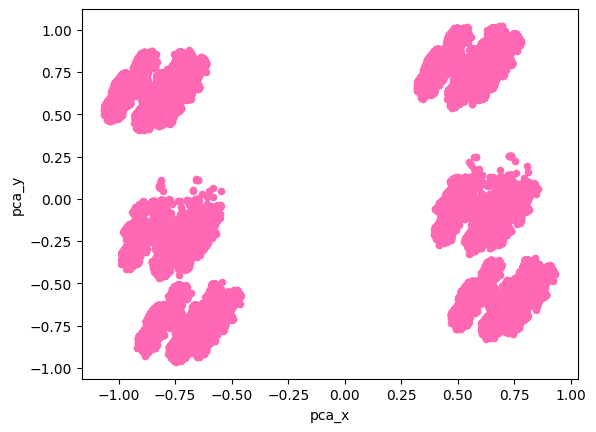

In [0]:
pca_df.select("pca_x", "pca_y").toPandas().plot.scatter(x="pca_x", y="pca_y", color='hotpink')

#### Choosing the Number of Clusters

The PCA plot suggests six broad groups: three on the left and three on the right. Based on this visual inspection, we selected `k = 6` for K-means. This is an exploratory choice rather than a quantitatively validated optimum.

In [0]:
c = 6

#### Clustering

Apply K-means to the full household feature vectors, not the two-dimensional PCA projection, using `k = 6` and `seed = 67`. Assign each household to a cluster and calculate its Euclidean distance from that cluster's centroid.

In [0]:
KMeans_model = KMeans(
    k=c, 
    featuresCol="features",
    predictionCol="cluster",
    seed = 67
)

KMeans_model = KMeans_model.fit(scaled_df)
clustered_df = KMeans_model.transform(scaled_df)

centroids = KMeans_model.clusterCenters()

clustered_df = clustered_df.withColumn(
    "features_array",
    vector_to_array("features")
)

In [0]:
distance_expr = None

for cluster_id, centroid in enumerate(centroids):

    squared_distance = None

    for feature_index, centroid_value in enumerate(centroid):

        current_squared_difference = (
            F.col("features_array")[feature_index]
            - F.lit(float(centroid_value))
        ) ** 2

        if squared_distance is None:
            squared_distance = current_squared_difference
        else:
            squared_distance = (
                squared_distance + current_squared_difference
            )

    current_distance = F.sqrt(squared_distance)

    condition = F.col("cluster") == cluster_id

    if distance_expr is None:
        distance_expr = F.when(
            condition,
            current_distance
        )
    else:
        distance_expr = distance_expr.when(
            condition,
            current_distance
        )

In [0]:
clustered_df = clustered_df.withColumn(
    "distance", 
    distance_expr)
display(clustered_df.select("household_id", "distance", "cluster").limit(7))

household_id,distance,cluster
85,1.470980014169766,0
2073,1.4405834098782142,0
2523,1.492071770152114,1
2717,1.4309378600934828,4
3364,0.5474451164836376,1
4046,0.871619579781442,0
4303,0.9355210685178114,4


#### Dividing Households into Subsets

Use a Window function to rank households within each cluster by increasing distance from the centroid. Create three subsets: all households (Full), every 6th household, and every 7th household. Subsets may overlap; for example, rank 42 belongs to all three.

Reuse these assignments in later analyses. The original ranking orders only by distance, so equal-distance households do not have an explicit tie-breaker.

In [0]:
window = Window.partitionBy("cluster").orderBy(F.col("distance").asc())

ranked_df = clustered_df.withColumn(
    "rank", 
    row_number().over(window))


In [0]:
subsets_df = ranked_df \
    .withColumn(
        "subsets",
        F.array(
            F.lit("Full"),
            F.when(F.col("rank") % 6 == 0, F.lit("6th")),
            F.when(F.col("rank") % 7 == 0, F.lit("7th"))
        )
    ) \
    .withColumn("subset", F.explode("subsets")) \
    .filter(F.col("subset").isNotNull()) \
    .select("household_id", "cluster", "subset")

#### Cluster's Viewing Analysis

Calculate each station's share of viewing events within every cluster subset and across the full static viewing dataset. Subtract the overall share from the subset share to obtain `diff_rank`, measured in percentage points.

Display the seven stations with the highest values per subset, grouping Full, 6th, and 7th results together for comparison. A positive value means the station has a higher event share in that subset; the measure is event-weighted, not an average giving equal weight to each household.

In [0]:
joined_df = viewing_static_df.join(
    subsets_df, 
    on = "household_id"
)

In [0]:
subsets_ratings = joined_df.groupBy(
    "cluster",
    "subset",
    "station_num"
).count()

subset_window = Window.partitionBy("cluster", "subset")

subsets_ratings = subsets_ratings.withColumn(
    "subset_rating", 
    F.col("count")/F.sum("count").over(subset_window) * 100
)

In [0]:
display(subsets_ratings.limit(7))

cluster,subset,station_num,count,subset_rating
0,6th,14902,3974,1.1899771227347316
0,6th,11007,490,0.14672591598893267
0,6th,10559,821,0.2458407694426811
0,6th,11062,70,0.020960845141276097
0,6th,46164,126,0.037729521254296974
0,6th,17124,71,0.02126028578615147
0,6th,31516,42,0.012576507084765659


In [0]:
total_ratings = viewing_static_df.groupBy("station_num") \
    .count() \
    .withColumn(
        "total_rating", 
        F.col("count")/F.sum("count").over(Window.partitionBy()) * 100
    )

display(total_ratings.limit(7))

station_num,count,total_rating
11317,8776,0.12150155206603172
31035,2826,0.03912527189364239
32414,644,0.008916020912776256
11458,7864,0.1088751373572554
11858,1777,0.0246021260279556
43714,497,0.006880842226164284
31236,863,0.01194802181323899


In [0]:
ratings_df = subsets_ratings \
    .join(
        F.broadcast(total_ratings.select("station_num", "total_rating")),
        on="station_num",
        how="left"
    ) \
    .withColumn(
        "diff_rank",
        F.col("subset_rating") - F.col("total_rating")
    )

In [0]:
subset_order = ["Full", "6th", "7th"]

for cluster_id in range(c):
    displayHTML(
        f"""<h2>Cluster {cluster_id}</h2>"""
    )
    for subset_name in subset_order:

        displayHTML(
            f"""<h3>Cluster {cluster_id} - {subset_name} Subset</h3>"""
        )

        display(
            ratings_df
            .filter(
                (F.col("cluster") == cluster_id) &
                (F.col("subset") == subset_name)
            )
            .orderBy(F.desc("diff_rank"))
            .limit(7)
        )

Cluster 0

Cluster 0 - Full Subset

station_num,cluster,subset,count,subset_rating,total_rating,diff_rank
74796,0,Full,16274,0.8011606343317564,0.6928191281322196,0.10834150619953686
60179,0,Full,30778,1.5151850807092786,1.4194609877705144,0.09572409293876416
14902,0,Full,23178,1.1410409968379902,1.0465525665195385,0.09448843031845167
16374,0,Full,32121,1.581300278688113,1.5008127562231126,0.08048752246500035
12574,0,Full,16481,0.8113511376687772,0.7403204755728024,0.07103066209597475
61522,0,Full,11937,0.5876523591015226,0.5228747854236349,0.06477757367788772
11158,0,Full,17215,0.8474855794531885,0.7900785177475197,0.05740706170566878


Cluster 0 - 6th Subset

station_num,cluster,subset,count,subset_rating,total_rating,diff_rank
16374,0,6th,5556,1.6944707066394216,1.5008127562231126,0.19365795041630895
12574,0,6th,2957,0.9018268321693251,0.7403204755728024,0.16150635659652268
74796,0,6th,2795,0.8524200189087804,0.6928191281322196,0.1596008907765608
14909,0,6th,1698,0.5178565982494129,0.3633001626896921,0.15455643555972076
47540,0,6th,1479,0.45106590624904697,0.31545269642485557,0.1356132098241914
14902,0,6th,3804,1.160145170636494,1.0465525665195385,0.11359260411695549
31709,0,6th,1026,0.3129098173167831,0.20505463624088377,0.10785518107589931


...

station_num,cluster,subset,count,subset_rating,total_rating,diff_rank
16615,5,Full,7594,1.215880416543915,0.8419963413855801,0.3738840751583349
35513,5,Full,4114,0.6586952901845756,0.3107039461560943,0.3479913440284813
11221,5,Full,7773,1.2445402262043526,0.9181147932154619,0.3264254329888907
12131,5,Full,8716,1.395524586594254,1.0974458784378078,0.2980787081564462
11207,5,Full,8834,1.4144176454765534,1.1513850360095101,0.2630326094670432
70387,5,Full,4804,0.769171651445479,0.5100683889262466,0.25910326251923244
10918,5,Full,6253,1.0011720100933765,0.7589278235646834,0.24224418652869317


Cluster 5 - 6th Subset

station_num,cluster,subset,count,subset_rating,total_rating,diff_rank
11221,5,6th,1663,1.6152060528948415,0.9181147932154619,0.6970912596793797
16615,5,6th,1428,1.3869598578074767,0.8419963413855801,0.5449635164218966
11207,5,6th,1664,1.6161773132994686,1.1513850360095101,0.4647922772899584
10035,5,6th,1206,1.1713400479802638,0.8481434117043265,0.3231966362759373
12574,5,6th,1052,1.0217659456676929,0.7403204755728024,0.2814454700948904
10142,5,6th,1187,1.1528861002923494,0.8768435846114463,0.2760425156809031
11066,5,6th,946,0.918812342777222,0.6655034305221147,0.2533089122551073


Cluster 5 - 7th Subset

station_num,cluster,subset,count,subset_rating,total_rating,diff_rank
35513,5,7th,546,0.618444600502911,0.3107039461560943,0.30774065434681663
21762,5,7th,403,0.4564710146569105,0.18538124227030134,0.27108977238660914
16300,5,7th,637,0.7215187005867295,0.4794161058503357,0.24210259473639378
12510,5,7th,318,0.360193009084113,0.12277526933928548,0.23741773974482752
11221,5,7th,1000,1.1326824185035,0.9181147932154619,0.2145676252880382
64241,5,7th,443,0.5017783113970504,0.2873478478954522,0.21443046350159822
66379,5,7th,457,0.5176358652560995,0.3158126600020795,0.20182320525401998


### Part B — Incremental Streaming Analysis

Read new viewing events from Kafka with Spark Structured Streaming. Reuse only the 6th subset from each demographic cluster and compare station shares against all events received by the stream.

Maintain cumulative station counts rather than collecting the complete raw event history. Each saved batch snapshot reflects the events processed so far; static viewing events are excluded from these streaming counts.

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from delta.tables import DeltaTable

#### Original Demonstration Setup

The following cells stop active queries and clear the demonstration's checkpoint and Delta paths before a fresh run. They are preserved for context and are not required to view the saved results.

In [0]:
for active_query in spark.streams.active:
    active_query.stop()
    active_query.awaitTermination()

print("Active queries:", len(spark.streams.active))

Active queries: 0


In [0]:
checkpoint_path = "dbfs:/tmp/checkpoints/viewing_stats"
delta_path_general = "dbfs:/tmp/delta/general_counts"
delta_path_subset = "dbfs:/tmp/delta/subset_counts"
delta_path_results = "dbfs:/tmp/delta/batch_results"

In [0]:
dbutils.fs.rm(checkpoint_path, True)
dbutils.fs.rm(delta_path_general, True)
dbutils.fs.rm(delta_path_subset, True)
dbutils.fs.rm(delta_path_results, True)

True

#### Kafka Input and Starter Preview

Parse Kafka messages into viewing-event fields and limit each trigger to at most 50,000 offsets. The first query is a starter preview of cumulative station counts; its printed loop counter is not the actual Spark batch ID.

In [0]:
SCHEMA = "device_id STRING, event_date INT, event_time INT, station_num STRING, prog_code STRING, household_id STRING"
kafka_server = "kafka.eastus.cloudapp.azure.com:29092"
topic = "view_data" 
OFFSETS_PER_TRIGGER = 50000

streaming_df = spark.readStream\
                  .format("kafka")\
                  .option("kafka.bootstrap.servers", kafka_server)\
                  .option("subscribe", topic)\
                  .option("startingOffsets", "earliest")\
                  .option("failOnDataLoss",False)\
                  .option("maxOffsetsPerTrigger", OFFSETS_PER_TRIGGER)\
                  .load()\
                  .select(from_csv(decode("value", "US-ASCII"), schema=SCHEMA).alias("value")).select("value.*")


########## QUERY EXAMPLE ##########

station_counts = streaming_df.groupBy("station_num").count()

count_viewings_per_station_query =station_counts.writeStream\
.queryName('num_viewing')\
.format("memory")\
.outputMode("complete")\
.trigger(availableNow=True)\
.start()

time.sleep(10)

for i in range(10):
    print("Batch number: "+str(i))
    print(count_viewings_per_station_query.status)
    spark.sql('SELECT * FROM num_viewing ORDER BY count DESC LIMIT 10').show()
    time.sleep(5)
    
count_viewings_per_station_query.stop()

Batch number: 0
{'message': 'Processing new data', 'isDataAvailable': True, 'isTriggerActive': True}
+-----------+-----+
|station_num|count|
+-----------+-----+
+-----------+-----+

Batch number: 1
{'message': 'Processing new data', 'isDataAvailable': True, 'isTriggerActive': True}
+-----------+-----+
|station_num|count|
+-----------+-----+
+-----------+-----+

Batch number: 2
{'message': 'Processing new data', 'isDataAvailable': True, 'isTriggerActive': True}
+-----------+-----+
|station_num|count|
+-----------+-----+
+-----------+-----+

Batch number: 3
{'message': 'Processing new data', 'isDataAvailable': True, 'isTriggerActive': True}
+-----------+-----+
|station_num|count|
+-----------+-----+
+-----------+-----+

Batch number: 4
{'message': 'Processing new data', 'isDataAvailable': True, 'isTriggerActive': True}
+-----------+-----+
|station_num|count|
+-----------+-----+
+-----------+-----+

Batch number: 5
{'message': 'Processing new data', 'isDataAvailable': True, 'isTriggerActi

#### Reuse the 6th Subsets

Prepare the existing household-to-cluster assignments for the 6th subset. Clustering is not refitted on incoming viewing events.

In [0]:
households_6_df = (
    subsets_df
    .filter(F.col("subset") == "6th")
    .select(
        F.col("household_id").cast("string").alias("household_id"),
        F.col("cluster").cast("int").alias("cluster")
    )
    .distinct()
)

#### Incremental Aggregation

For each non-empty batch, count events by station for the whole stream and by cluster and station for the selected households. Add these counts to Delta tables, calculate cumulative station shares and `diff_rank`, and save the top seven stations per cluster with the batch ID.

In [0]:
def process_batch(batch_df, batch_id):

    print(f"\n========== Processing Batch {batch_id} ==========")

    # Skip empty batches
    if batch_df.isEmpty():
        print("The batch is empty.")
        return

    # Count station views in the entire current streamed batch
    batch_general = (
        batch_df
        .groupBy("station_num")
        .agg(F.count("*").alias("general_count"))
    )

    # Count station views only for households in the 6th subset
    batch_subset = (
        batch_df
        .join(
            F.broadcast(households_6_df),
            on="household_id",
            how="inner"
        )
        .groupBy("cluster", "station_num")
        .agg(F.count("*").alias("subset_count"))
    )

    # Update cumulative general station counts
    try:
        general_delta = DeltaTable.forPath(
            spark,
            delta_path_general
        )

        (
            general_delta.alias("old")
            .merge(
                batch_general.alias("new"),
                "old.station_num = new.station_num"
            )
            .whenMatchedUpdate(
                set={
                    "general_count":
                    "old.general_count + new.general_count"
                }
            )
            .whenNotMatchedInsert(
                values={
                    "station_num": "new.station_num",
                    "general_count": "new.general_count"
                }
            )
            .execute()
        )

    except Exception:
        (
            batch_general.write
            .format("delta")
            .mode("overwrite")
            .save(delta_path_general)
        )

    # Update cumulative counts for the 6th subset
    try:
        subset_delta = DeltaTable.forPath(
            spark,
            delta_path_subset
        )

        (
            subset_delta.alias("old")
            .merge(
                batch_subset.alias("new"),
                """
                old.cluster = new.cluster
                AND old.station_num = new.station_num
                """
            )
            .whenMatchedUpdate(
                set={
                    "subset_count":
                    "old.subset_count + new.subset_count"
                }
            )
            .whenNotMatchedInsert(
                values={
                    "cluster": "new.cluster",
                    "station_num": "new.station_num",
                    "subset_count": "new.subset_count"
                }
            )
            .execute()
        )

    except Exception:
        (
            batch_subset.write
            .format("delta")
            .mode("overwrite")
            .save(delta_path_subset)
        )

    # Read the cumulative counts
    cumulative_general = (
        spark.read
        .format("delta")
        .load(delta_path_general)
    )

    cumulative_subset = (
        spark.read
        .format("delta")
        .load(delta_path_subset)
    )

    # Calculate the general station rating
    general_window = Window.partitionBy()

    general_ratings = (
        cumulative_general
        .withColumn(
            "general_rating",
            F.col("general_count")
            / F.sum("general_count").over(general_window)
            * 100
        )
    )

    # Calculate the station rating inside each cluster's 6th subset
    cluster_window = Window.partitionBy("cluster")

    subset_ratings = (
        cumulative_subset
        .withColumn(
            "subset_rating",
            F.col("subset_count")
            / F.sum("subset_count").over(cluster_window)
            * 100
        )
    )

    # Calculate diff_rank
    ratings = (
        subset_ratings
        .join(
            general_ratings.select(
                "station_num",
                "general_count",
                "general_rating"
            ),
            on="station_num",
            how="left"
        )
        .withColumn(
            "diff_rank",
            F.col("subset_rating")
            - F.col("general_rating")
        )
    )

    # Select the top 7 stations inside each cluster
    rank_window = (
        Window
        .partitionBy("cluster")
        .orderBy(
            F.desc("diff_rank"),
            F.asc("station_num")
        )
    )

    top_7 = (
        ratings
        .withColumn(
            "rank",
            F.row_number().over(rank_window)
        )
        .filter(F.col("rank") <= 7)
        .withColumn("batch_id", F.lit(batch_id))
        .select(
            "batch_id",
            "cluster",
            "rank",
            "station_num",
            "subset_count",
            "subset_rating",
            "general_count",
            "general_rating",
            "diff_rank"
        )
    )

    # Save the result snapshot for the current batch
    (
        top_7.write
        .format("delta")
        .mode("append")
        .save(delta_path_results)
    )

    # Output
    for cluster_id in range(6):
        print(
            f"\nBatch {batch_id} - "
            f"Cluster {cluster_id} - 6th Subset"
        )

        (
            top_7
            .filter(F.col("cluster") == cluster_id)
            .orderBy("rank")
            .show(7, truncate=False)
        )

#### Execute the Streaming Demonstration

Run the batch handler with a checkpoint and stop the demonstration after four result batch IDs have been saved. The original run logged an interruption during result display when the query was stopped. That traceback is omitted here for readability; saved result snapshots are inspected below.

In [0]:
from delta.tables import DeltaTable
import time

query = (
    streaming_df.writeStream
    .foreachBatch(process_batch)
    .option("checkpointLocation", checkpoint_path)
    .trigger(availableNow=True)
    .start()
)

while query.isActive:

    try:
        completed_batches = (
            spark.read
            .format("delta")
            .load(delta_path_results)
            .select("batch_id")
            .distinct()
            .count()
        )

    except Exception:
        print("Waiting for Batch 0 to finish...")
        time.sleep(10)
        continue

    print(f"Completed batches: {completed_batches}")

    if completed_batches >= 4:
        query.stop()
        break

    time.sleep(1)


========== Processing Batch 0 ==========
Waiting for Batch 0 to finish...
Waiting for Batch 0 to finish...
Waiting for Batch 0 to finish...

Batch 0 - Cluster 0 - 6th Subset
+--------+-------+----+-----------+------------+------------------+-------------+-------------------+-------------------+
|batch_id|cluster|rank|station_num|subset_count|subset_rating     |general_count|general_rating     |diff_rank          |
+--------+-------+----+-----------+------------+------------------+-------------+-------------------+-------------------+
|0       |0      |1   |10179      |59          |2.3543495610534717|960          |1.92               |0.4343495610534718 |
|0       |0      |2   |57391      |23          |0.9177972865123704|257          |0.514              |0.40379728651237035|
|0       |0      |3   |16062      |17          |0.6783719074221868|144          |0.28800000000000003|0.39037190742218675|
|0       |0      |4   |50747      |23          |0.9177972865123704|275          |0.5499999999

#### Review Saved Batch Results

Read the persisted results, list the available batch IDs, and display the first three batches separately for every cluster's 6th subset. These are cumulative snapshots, so consecutive batches share previously processed events.

In [0]:
batch_results_df = (
    spark.read
    .format("delta")
    .load(delta_path_results)
)

In [0]:
display(
    batch_results_df
    .select("batch_id")
    .distinct()
    .orderBy("batch_id")
)

batch_id
0
1
2
3


In [0]:
batch_ids = [
    row["batch_id"]
    for row in (
        batch_results_df
        .select("batch_id")
        .distinct()
        .orderBy("batch_id")
        .limit(3)
        .collect()
    )
]

for batch_id in batch_ids:
    displayHTML(f"<h1>Batch {batch_id}</h1>")

    for cluster_id in range(6):
        displayHTML(
            f"<h2>Cluster {cluster_id} - 6th Subset</h2>"
        )

        display(
            batch_results_df
            .filter(
                (F.col("batch_id") == batch_id)
                & (F.col("cluster") == cluster_id)
            )
            .orderBy("rank")
        )

Batch 0

Cluster 0 - 6th Subset

batch_id,cluster,rank,station_num,subset_count,subset_rating,general_count,general_rating,diff_rank
0,0,1,10179,59,2.3543495610534717,960,1.92,0.4343495610534718
0,0,2,57391,23,0.9177972865123704,257,0.514,0.40379728651237035
0,0,3,16062,17,0.6783719074221868,144,0.28800000000000003,0.39037190742218675
0,0,4,50747,23,0.9177972865123704,275,0.5499999999999999,0.3677972865123704
0,0,5,10021,28,1.1173184357541899,387,0.774,0.34331843575418985
0,0,6,45507,18,0.7182761372705506,206,0.41200000000000003,0.3062761372705506
0,0,7,11069,19,0.7581803671189146,227,0.45399999999999996,0.3041803671189146


Cluster 1 - 6th Subset

batch_id,cluster,rank,station_num,subset_count,subset_rating,general_count,general_rating,diff_rank
0,1,1,14765,38,1.4763014763014763,424,0.848,0.6283014763014764
0,1,2,32645,82,3.1857031857031854,1332,2.664,0.5217031857031853
0,1,3,14771,32,1.2432012432012431,460,0.9199999999999999,0.3232012432012432
0,1,4,60048,24,0.9324009324009324,317,0.634,0.29840093240093235
0,1,5,57394,15,0.5827505827505828,163,0.326,0.25675058275058277
0,1,6,18822,12,0.4662004662004662,108,0.216,0.2502004662004662
0,1,7,14766,12,0.4662004662004662,111,0.22200000000000003,0.24420046620046615


...

batch_id,cluster,rank,station_num,subset_count,subset_rating,general_count,general_rating,diff_rank
2,3,1,60179,50,1.6254876462938883,1122,0.748,0.8774876462938883
2,3,2,32645,93,3.023407022106632,3374,2.2493333333333334,0.7740736887732984
2,3,3,62077,24,0.7802340702210664,154,0.10266666666666666,0.6775674035543997
2,3,4,10121,20,0.6501950585175552,129,0.086,0.5641950585175552
2,3,5,60222,21,0.6827048114434331,227,0.15133333333333332,0.5313714781100998
2,3,6,58649,17,0.5526657997399219,77,0.05133333333333333,0.5013324664065886
2,3,7,10120,18,0.5851755526657998,145,0.09666666666666666,0.4885088859991331


Cluster 4 - 6th Subset

batch_id,cluster,rank,station_num,subset_count,subset_rating,general_count,general_rating,diff_rank
2,4,1,59337,39,1.1828935395814377,806,0.5373333333333333,0.6455602062481044
2,4,2,34710,16,0.48528965726417955,175,0.11666666666666668,0.36862299059751286
2,4,3,10458,18,0.5459508644222021,389,0.25933333333333336,0.2866175310888687
2,4,4,11221,48,1.4558689717925388,1783,1.1886666666666668,0.26720230512587206
2,4,5,10145,32,0.9705793145283591,1060,0.7066666666666667,0.26391264786169244
2,4,6,10269,17,0.5156202608431908,384,0.256,0.2596202608431908
2,4,7,15433,16,0.48528965726417955,377,0.2513333333333333,0.23395632393084625


Cluster 5 - 6th Subset

batch_id,cluster,rank,station_num,subset_count,subset_rating,general_count,general_rating,diff_rank
2,5,1,11221,55,2.4531668153434434,1783,1.1886666666666668,1.2645001486767766
2,5,2,10035,31,1.3826940231935771,901,0.6006666666666667,0.7820273565269105
2,5,3,59615,23,1.0258697591436219,631,0.4206666666666667,0.6052030924769551
2,5,4,12574,28,1.2488849241748439,1062,0.7080000000000001,0.5408849241748438
2,5,5,10021,30,1.3380909901873328,1234,0.8226666666666667,0.5154243235206661
2,5,6,11207,31,1.3826940231935771,1351,0.9006666666666666,0.48202735652691053
2,5,7,11865,16,0.7136485280999109,412,0.27466666666666667,0.4389818614332442


## Interpretation and Limitations

The saved outputs demonstrate distributed aggregations, demographic feature preparation, clustering, and cumulative streaming analysis in the original Databricks environment. Cluster labels are arbitrary identifiers, and differences in event shares do not establish causal relationships between demographics and viewing preferences.

The original streaming handler uses additive updates without batch-level replay protection. Retrying a batch can double-count events, and its broad exception fallback can replace accumulated counts. It should be treated as a coursework demonstration, not an exactly-once production pipeline.

All executable code is preserved unchanged. Saved results are retained, with long tables limited to their first 20 saved rows for readability. The query-cancellation traceback is omitted. The explanations document the original behavior; this presentation update does not imply that the noted limitations have been corrected or that the combined notebook has been rerun.